## Problem Statement

### Business context

Employee Promotion means the ascension of an employee to higher ranks, this aspect of the job is what drives employees the most. The ultimate reward for dedication and loyalty towards an organization and the HR team plays an important role in handling all these promotion tasks based on ratings and other attributes available.

The HR team in JMD company stored data on the promotion cycle last year, which consists of details of all the employees in the company working last year and also if they got promoted or not, but every time this process gets delayed due to so many details available for each employee - it gets difficult to compare and decide.


### Objective

For the upcoming appraisal cycle, the HR team wants to utilize the stored data and leverage machine learning to make a model that will predict if a person is eligible for promotion or not. You, as a data scientist at JMD company, need to come up with the best possible model that will help the HR team to predict if a person is eligible for promotion or not.


### Data Description

- employee_id: Unique ID for the employee
- department: Department of employee
- region: Region of employment (unordered)
- education: Education Level
- gender: Gender of Employee
- recruitment_channel: Channel of recruitment for employee
- no_ of_ trainings: no of other training completed in the previous year on soft skills, technical skills, etc.
- age: Age of Employee
- previous_ year_ rating: Employee Rating for the previous year
- length_ of_ service: Length of service in years
- awards_ won: if awards won during the previous year then 1 else 0
- avg_ training_ score: Average score in current training evaluations
- is_promoted: (Target) Recommended for promotion

### Importing the required libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier

from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### Load the data and understand the structure

In [7]:
employee_promotion = pd.read_csv("/root/nikhimeh/Advanced_machine_learning/Employee_promotion/employee_promotion.csv")
employee_promotion.head()   # check first few rows

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60.0,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50.0,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73.0,0


### Criteria 1
### Exploratory Data Analysis and Insights
- Problem definition, questions to be answered
- Data background and contents
- Univariate analysis
- Bivariate analysis
- Key meaningful observations on individual variables and the relationship between variables

##### How many rows and columns are present in the data?

In [8]:
rows, columns = employee_promotion.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 54808
Number of columns: 13


##### Observations:
There are 54808 rows and 13 columns in the data

#####  What are the datatypes of the different columns in the dataset?

In [9]:
print(employee_promotion.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won            54808 non-null  int64  
 11  avg_training_score    52248 non-null  float64
 12  is_promoted           54808 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 5.4+ MB
None


###  Check the statistical summary of the data ?

In [10]:
print("Overall Statistical Summary:")
employee_promotion.describe(include='all').T

Overall Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
employee_id,54808.0,NaN,NaN,NaN,39195.830627,22586.581449,1.0,19669.75,39225.5,58730.5,78298.0
department,54808,9,Sales & Marketing,16840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,54808,34,region_2,12343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,52399,3,Bachelor's,36669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,54808,2,m,38496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
recruitment_channel,54808,3,other,30446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_trainings,54808.0,NaN,NaN,NaN,1.253011,0.609264,1.0,1.0,1.0,1.0,10.0
age,54808.0,NaN,NaN,NaN,34.803915,7.660169,20.0,29.0,33.0,39.0,60.0
previous_year_rating,50684.0,NaN,NaN,NaN,3.329256,1.259993,1.0,3.0,3.0,4.0,5.0
length_of_service,54808.0,NaN,NaN,NaN,5.865512,4.265094,1.0,3.0,5.0,7.0,37.0


- The dataset has 54808 rows and 13 columns
- There are  missing values in the columns ("education", "previous_year_rating", "avg_training_score")
- There are no duplicate values in the dataset
- The most common educational level is Bachelor
- There are more males

### Univariate Analysis

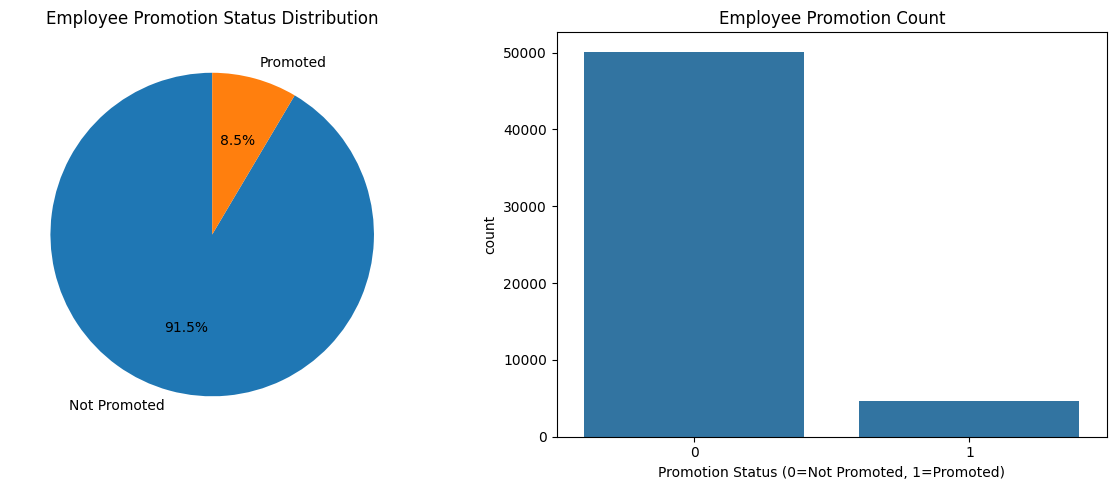

Employee Promotion Status distribution:
0    50140
1     4668
Name: is_promoted, dtype: int64


In [11]:
# 1. TARGET VARIABLE ANALYSIS
plt.figure(figsize=(12, 5))

# Employee Promotion Status Distribution
plt.subplot(1, 2, 1)
promotion_counts = employee_promotion['is_promoted'].value_counts()
plt.pie(promotion_counts.values, labels=['Not Promoted', 'Promoted'], autopct='%1.1f%%', startangle=90)
plt.title('Employee Promotion Status Distribution')

plt.subplot(1, 2, 2)
sns.countplot(data=employee_promotion, x='is_promoted')
plt.title('Employee Promotion Count')
plt.xlabel('Promotion Status (0=Not Promoted, 1=Promoted)')

plt.tight_layout()
plt.show()

print(f"Employee Promotion Status distribution:")
print(employee_promotion['is_promoted'].value_counts())

#### Observations:
As per last year data - around 8.5% employees were promoted

In [12]:
# for numerical variables
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram
    plt.show()

# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

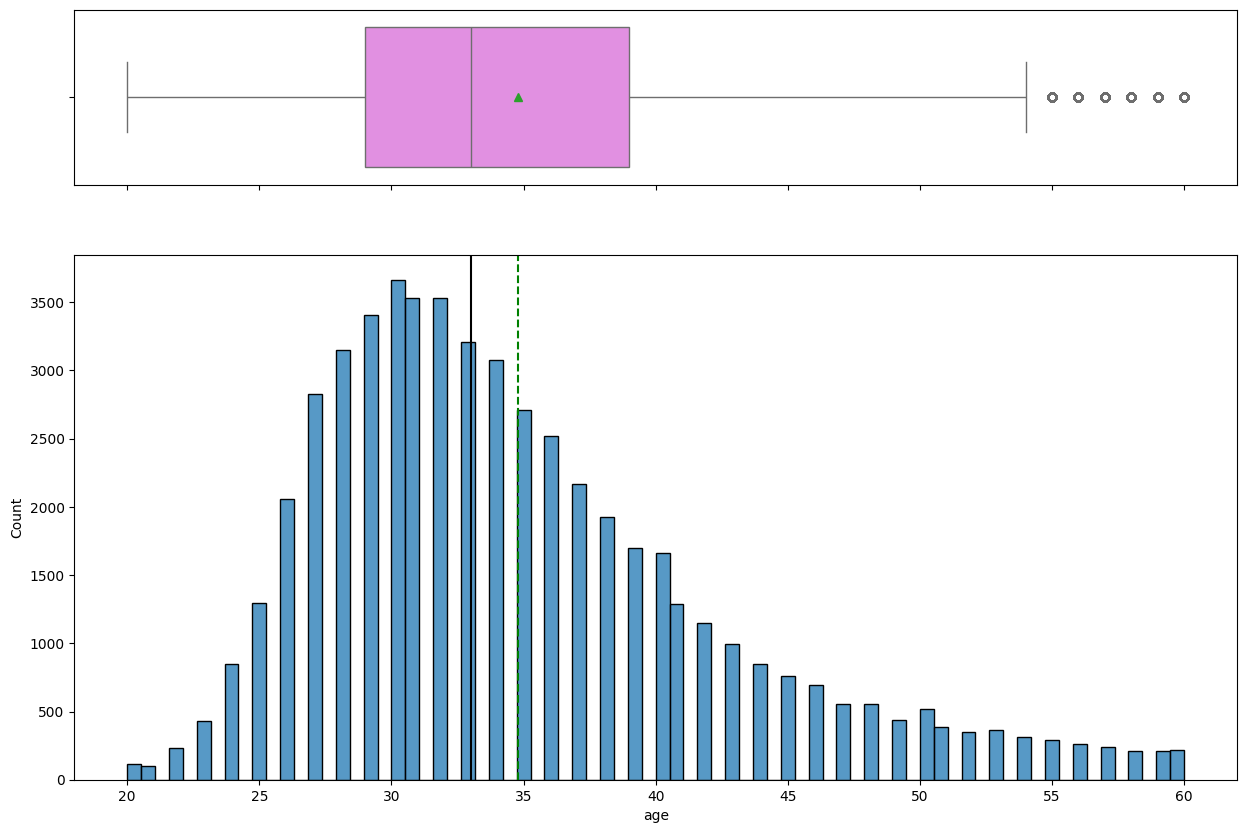

In [13]:
# No of employees distribution as per their age
histogram_boxplot(employee_promotion,'age')

- The median age is in mid 30s. There are few outliers but they seems to be either early joiners (mostly freshers) or employees near retirement age

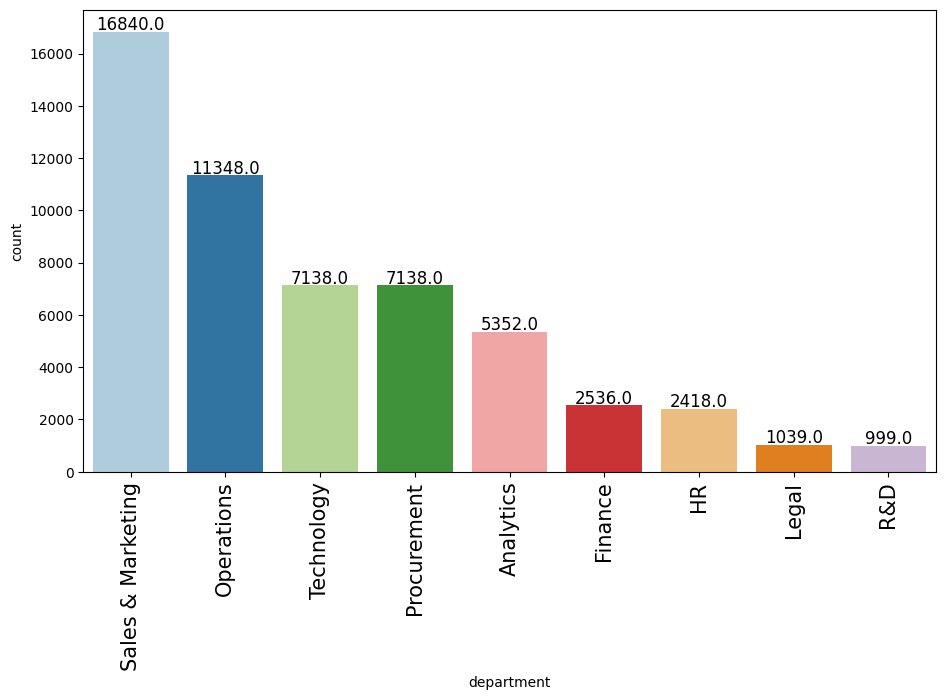

In [14]:
# No of employees distribution as per their department
labeled_barplot(employee_promotion,'department')

- The most employees are from sales and marketing team

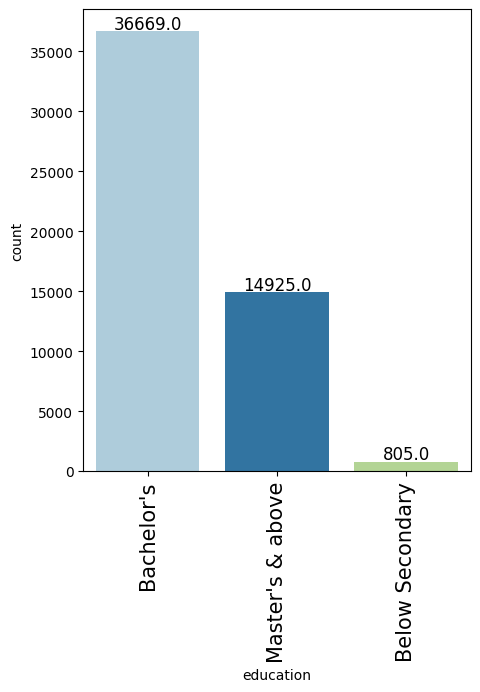

In [15]:
# No of employees distribution as per their region
labeled_barplot(employee_promotion,'education')

- The most employees are having Bachelor's degree. There are very few with below secondary degree. 

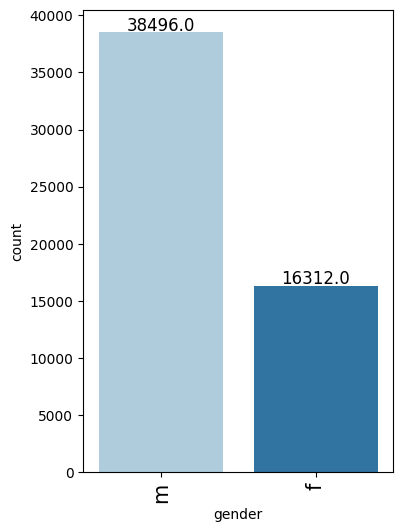

In [16]:
# No of employees distribution as per their gender
labeled_barplot(employee_promotion,'gender')

- There are more male employees

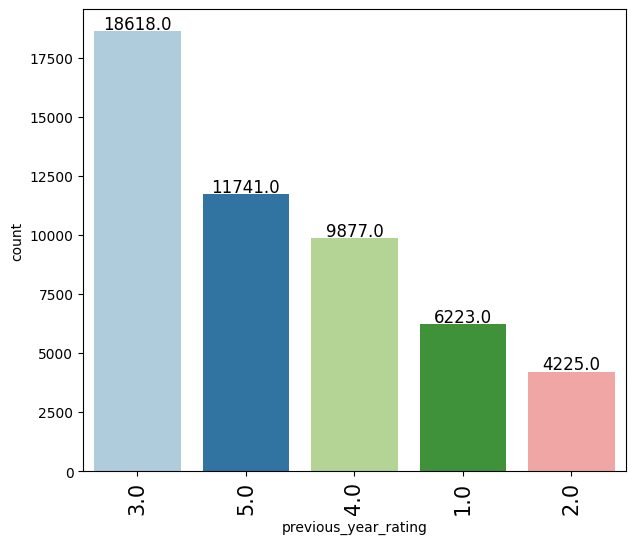

In [17]:
# No of employees distribution as per their previous year rating
labeled_barplot(employee_promotion,'previous_year_rating')

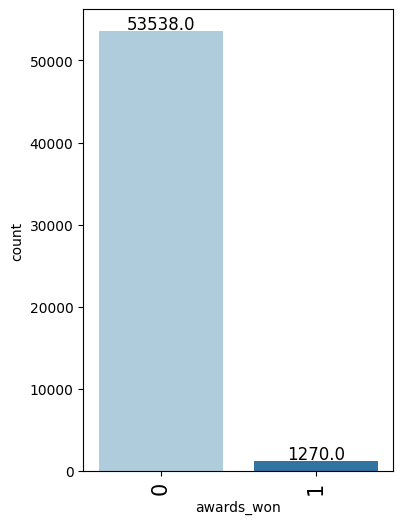

In [18]:
# No of employees distribution as per awards won
labeled_barplot(employee_promotion,'awards_won')

- There are very few who won the awards. Logically, there should be high correlation between awards won and promotion. We will check that in heat map

### Bivariate Analysis

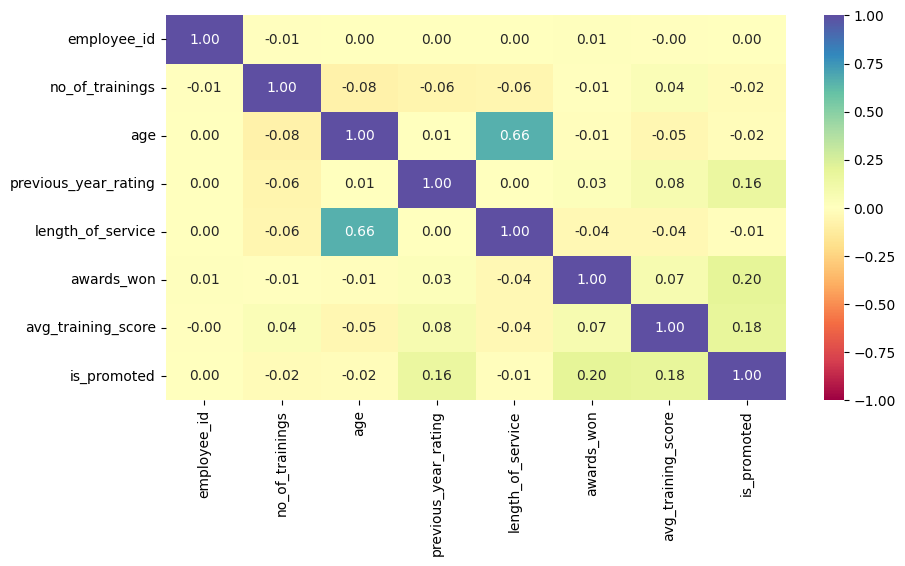

In [19]:
# seperate the numerical values
cols_list = employee_promotion.select_dtypes(include=np.number).columns.tolist()

# create the correlation matrix
plt.figure(figsize=(10, 5))
sns.heatmap(
    employee_promotion[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

- We dont see much correlation between the numerical columns

In [20]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()


is_promoted            0     1    All
department                           
All                50140  4668  54808
Sales & Marketing  15627  1213  16840
Operations         10325  1023  11348
Technology          6370   768   7138
Procurement         6450   688   7138
Analytics           4840   512   5352
Finance             2330   206   2536
HR                  2282   136   2418
R&D                  930    69    999
Legal                986    53   1039
------------------------------------------------------------------------------------------------------------------------


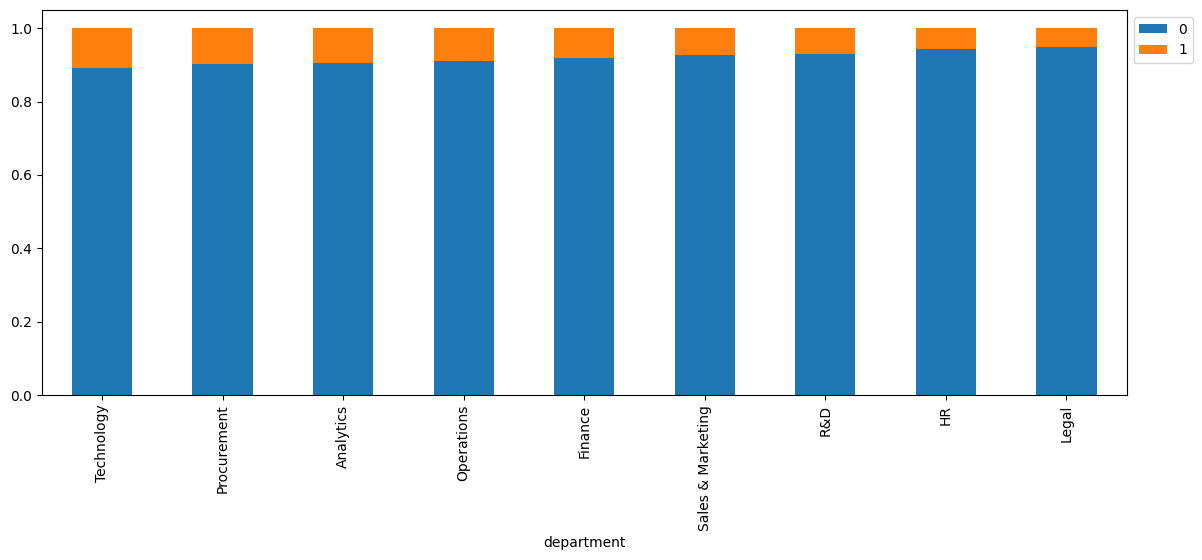

In [21]:
# Promotion of Employees vs department
stacked_barplot(employee_promotion, "department", "is_promoted")

- Promotion is done in all the department

is_promoted      0     1    All
gender                         
All          50140  4668  54808
m            35295  3201  38496
f            14845  1467  16312
------------------------------------------------------------------------------------------------------------------------


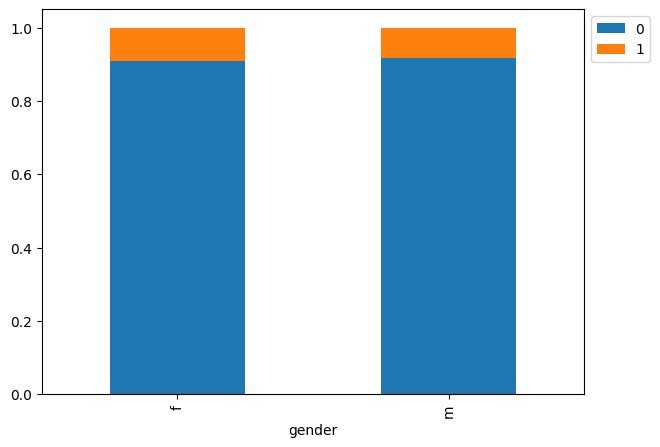

In [22]:
# Promotion of Employees vs gender
stacked_barplot(employee_promotion, "gender", "is_promoted")

- Employees are promoted irrespective of their gender

is_promoted      0     1    All
awards_won                     
All          50140  4668  54808
0            49429  4109  53538
1              711   559   1270
------------------------------------------------------------------------------------------------------------------------


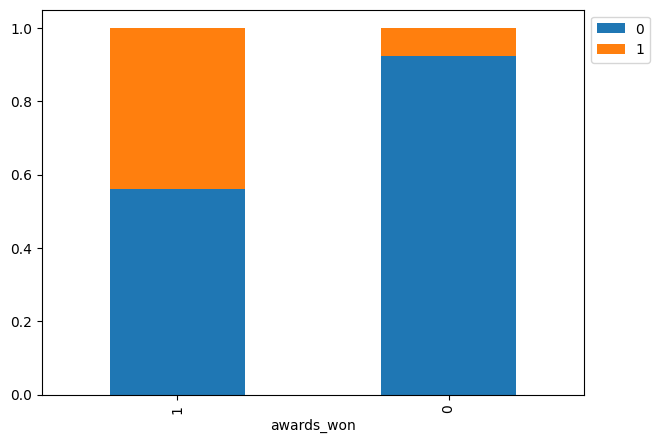

In [23]:
# Promotion of Employees vs awards won
stacked_barplot(employee_promotion, "awards_won", "is_promoted")

- As expected, those who won the awards have more chances of promotion

is_promoted               0     1    All
previous_year_rating                    
All                   46355  4329  50684
5.0                    9820  1921  11741
3.0                   17263  1355  18618
4.0                    9093   784   9877
2.0                    4044   181   4225
1.0                    6135    88   6223
------------------------------------------------------------------------------------------------------------------------


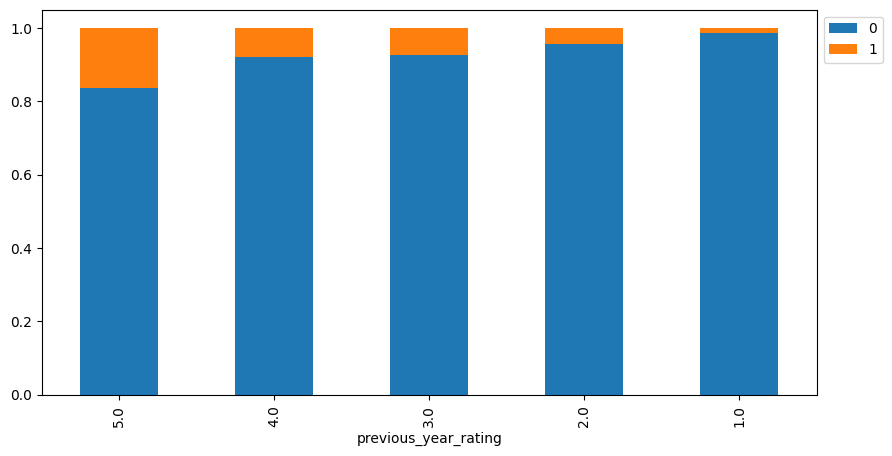

In [24]:
# Promotion of Employees vs previous_year_rating
stacked_barplot(employee_promotion, "previous_year_rating", "is_promoted")

- Those who got high rating in previous year has more chance of promotion as expected

### Criteria 2
### Data pre-processing
- Prepare the data for analysis
- Feature Engineering
- Missing value Treatment
- Outlier Treatment

Note: Please ensure no data leakage occurs among train-test and validation sets

#####  Are there any missing values in the data? If yes, treat them using an appropriate method?

In [25]:
missing_data = employee_promotion.isnull().sum()
print("Missing values per column:")
print(missing_data)

Missing values per column:
employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won                 0
avg_training_score      2560
is_promoted                0
dtype: int64


##### Observations:
We have three columns where we have missing values
- Education 
- Previous_year_rating 
- avg_training_score

We will see the missing rows and see if there is any pattern in those missing rows

In [26]:
employee_promotion[employee_promotion['education'].isnull()]

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
10,29934,Technology,region_23,NaN,m,sourcing,1,30,NaN,1,0,77.0,0
21,33332,Operations,region_15,NaN,m,sourcing,1,41,4.0,11,0,57.0,0
32,35465,Sales & Marketing,region_7,NaN,f,sourcing,1,24,1.0,2,0,48.0,0
43,17423,Sales & Marketing,region_2,NaN,m,other,3,24,2.0,2,0,48.0,0
82,66013,Sales & Marketing,region_2,NaN,m,sourcing,2,25,3.0,2,0,53.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54692,14821,Sales & Marketing,region_2,NaN,f,sourcing,1,35,3.0,7,0,53.0,0
54717,7684,Analytics,region_2,NaN,m,sourcing,1,32,3.0,4,0,86.0,0
54729,1797,HR,region_2,NaN,f,other,1,28,3.0,2,0,53.0,0
54742,38935,Sales & Marketing,region_31,NaN,m,other,1,28,4.0,3,0,47.0,0


#####  We dont see any pattern here so we will replace the missing values with mode since this is an ordinal variable

In [27]:
#fill the missing values in education with the mode
employee_promotion['education']=employee_promotion['education'].fillna(employee_promotion.education.mode()[0])

In [28]:
employee_promotion[employee_promotion['previous_year_rating'].isnull()]

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
10,29934,Technology,region_23,Bachelor's,m,sourcing,1,30,NaN,1,0,77.0,0
23,71177,Procurement,region_5,Bachelor's,m,other,1,27,NaN,1,0,70.0,0
29,74759,Sales & Marketing,region_4,Bachelor's,m,sourcing,1,26,NaN,1,0,44.0,0
56,45709,Sales & Marketing,region_31,Bachelor's,f,other,1,29,NaN,1,0,49.0,0
58,26599,Sales & Marketing,region_16,Bachelor's,m,other,2,27,NaN,1,0,47.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54703,74615,R&D,region_31,Bachelor's,m,sourcing,1,30,NaN,1,0,88.0,0
54734,11685,Operations,region_15,Bachelor's,m,sourcing,1,31,NaN,1,0,56.0,1
54746,10546,Finance,region_6,Bachelor's,m,other,1,28,NaN,1,0,NaN,0
54773,37919,Finance,region_2,Bachelor's,m,other,1,23,NaN,1,0,NaN,0


##### We see that previous_year_rating is null when length of service is 1. That means this is null for those who joined only this year so there is no previous year rating data available. We can mark all these missing values with 0. 

In [29]:
employee_promotion['previous_year_rating']=employee_promotion['previous_year_rating'].fillna(0)

In [30]:
employee_promotion[employee_promotion['avg_training_score'].isnull()]

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
31,58536,Finance,region_31,Bachelor's,m,other,2,26,1.0,2,0,NaN,0
67,16502,Sales & Marketing,region_22,Bachelor's,m,sourcing,1,27,0.0,1,0,NaN,1
128,42068,Operations,region_1,Master's & above,m,other,1,38,5.0,9,0,NaN,0
159,30106,Sales & Marketing,region_16,Bachelor's,f,sourcing,1,32,4.0,4,0,NaN,0
166,4134,Sales & Marketing,region_16,Bachelor's,f,other,1,39,1.0,8,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54701,23170,Sales & Marketing,region_28,Master's & above,m,other,1,39,1.0,11,0,NaN,0
54736,38707,Operations,region_31,Bachelor's,m,other,1,34,5.0,6,0,NaN,0
54746,10546,Finance,region_6,Bachelor's,m,other,1,28,0.0,1,0,NaN,0
54773,37919,Finance,region_2,Bachelor's,m,other,1,23,0.0,1,0,NaN,0


##### For avg_training_score column, we dont see any pattern. We will do linear interpolation for this column to replace the missing values

In [31]:
employee_promotion.interpolate(inplace=True)

In [32]:
employee_promotion.isnull().sum()

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won              0
avg_training_score      0
is_promoted             0
dtype: int64

### Now we dont have any missing values

In [33]:
# Outliers are only posssible in numerical data, let's analyze the numerical columns
employee_promotion.select_dtypes('number').columns.to_list()

['employee_id',
 'no_of_trainings',
 'age',
 'previous_year_rating',
 'length_of_service',
 'awards_won',
 'avg_training_score',
 'is_promoted']

- An outlier can only exists in the avg_training score and length_of_service columns. As other variables have a limited number of values.

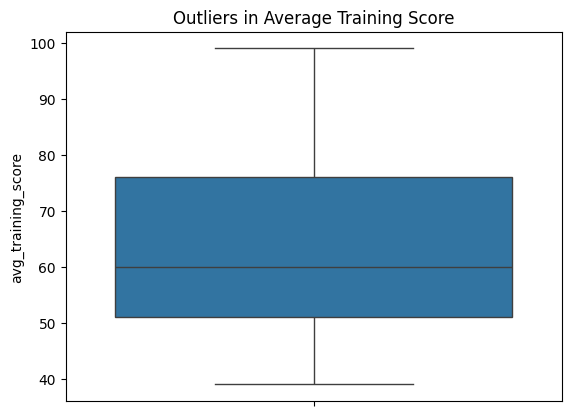

In [34]:
sns.boxplot(data=employee_promotion, y='avg_training_score')
plt.title('Outliers in Average Training Score')
plt.show()

- There is no outlier in Average training score

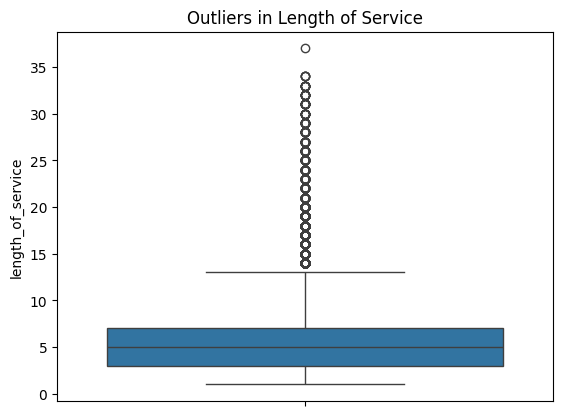

In [35]:
sns.boxplot(data=employee_promotion, y='length_of_service')
plt.title('Outliers in Length of Service')
plt.show()

In [36]:
# Calculate quartiles and IQR
Q1 = employee_promotion['length_of_service'].quantile(0.25)
Q3 = employee_promotion['length_of_service'].quantile(0.75)
IQR = Q3 - Q1

# Define upper whisker (max without outliers)
upper_whisker = Q3 + 1.5 * IQR
lower_whisker = Q1 - 1.5 * IQR

print("Upper whisker limit (max without outliers):", upper_whisker)
print("Lower whisker limit (min without outliers):", lower_whisker)


Upper whisker limit (max without outliers): 13.0
Lower whisker limit (min without outliers): -3.0


- Since we have few outliers in length of service, we can limit the outliers to the maximum values which is 13

In [37]:
employee_promotion['length_of_service']=np.where( employee_promotion['length_of_service']>13,13, employee_promotion['length_of_service'])
employee_promotion['length_of_service'].max()

13

In [38]:
employee_promotion.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60.0,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50.0,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73.0,0


### Since employee_id may not be relavant for prediction, we would drop this column. Also We would apply label encoder in the columns which is of type object

In [39]:
employee_promotion.drop('employee_id',axis=1,inplace=True)

In [40]:
l=LabelEncoder()
for employee in employee_promotion.columns:
    if employee_promotion[employee].dtype == 'object':
        employee_promotion[employee]=l.fit_transform(employee_promotion[employee])


In [41]:
employee_promotion.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,7,31,2,0,2,1,35,5.0,8,0,49.0,0
1,4,14,0,1,0,1,30,5.0,4,0,60.0,0
2,7,10,0,1,2,1,34,3.0,7,0,50.0,0
3,7,15,0,1,0,2,39,1.0,10,0,50.0,0
4,8,18,0,1,0,1,45,3.0,2,0,73.0,0


In [42]:
# Separate features (X) and target variable (Y)

# Drop the target column 'is_promoted' from the dataset 
X = employee_promotion.drop(["is_promoted"], axis=1)

# Extract the target column 'is_promoted' as the label vector Y
Y = employee_promotion["is_promoted"]

In [43]:
# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y
)

print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (38365, 11)
Shape of test set :  (16443, 11)
Percentage of classes in training set:
0    0.914818
1    0.085182
Name: is_promoted, dtype: float64
Percentage of classes in test set:
0    0.914857
1    0.085143
Name: is_promoted, dtype: float64


### Criteria 3
### Model Building - Original Data
- Build 5 models (from decision trees, bagging, and boosting methods)
- Comment on the model performance

You can choose NOT to build XGBoost if you are facing issues with the installation

In [44]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn

def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

def confusion_matrix_sklearn(model, predictors, target, title="Confusion Matrix"):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title(title)
    plt.show()

Model: DecisionTreeClassifier
------------------------------------------------------------------------------------------------------------------------


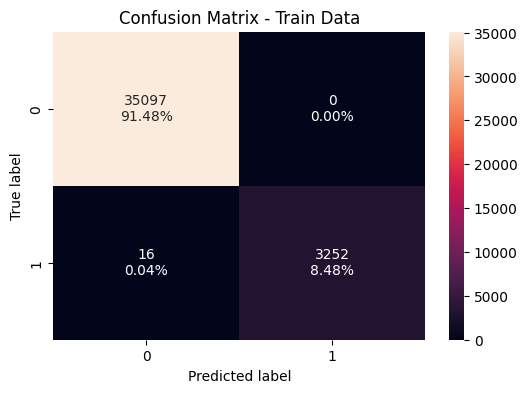

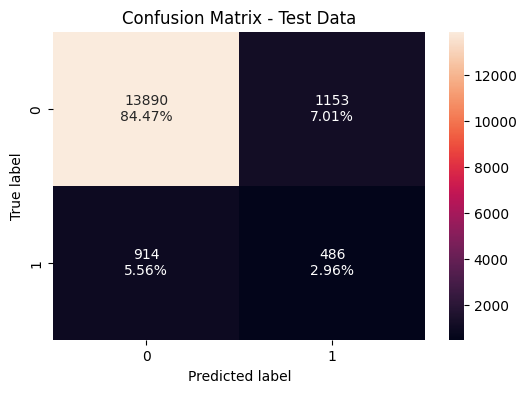

Model: BaggingClassifier
------------------------------------------------------------------------------------------------------------------------


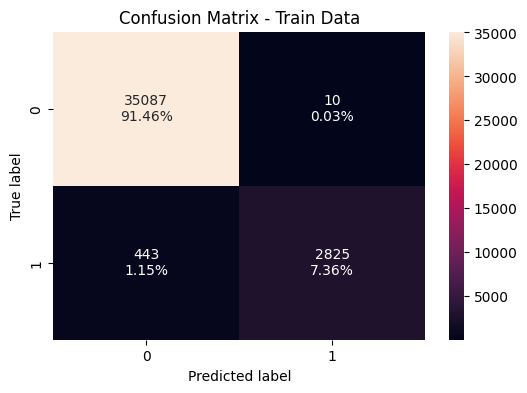

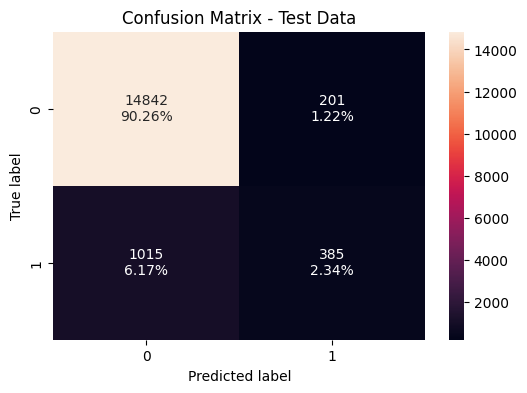

Model: RandomForestClassifier
------------------------------------------------------------------------------------------------------------------------


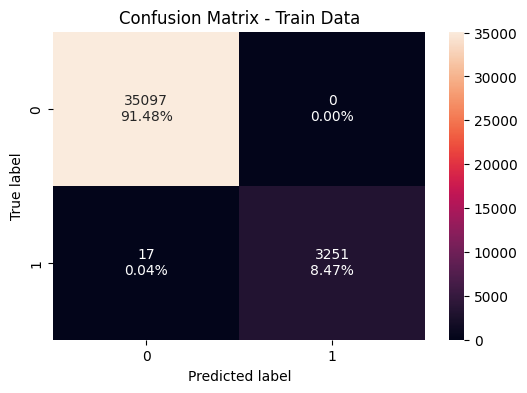

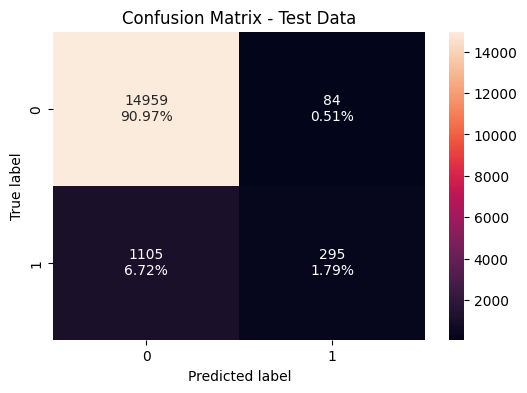

Model: AdaBoostClassifier
------------------------------------------------------------------------------------------------------------------------


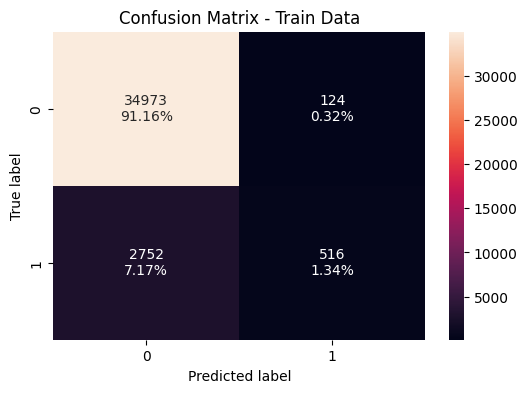

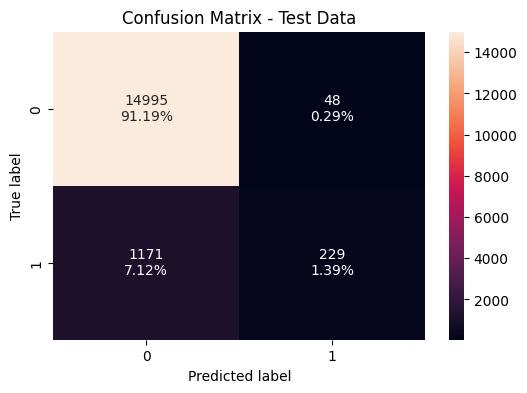

Model: GradientBoostingClassifier
------------------------------------------------------------------------------------------------------------------------


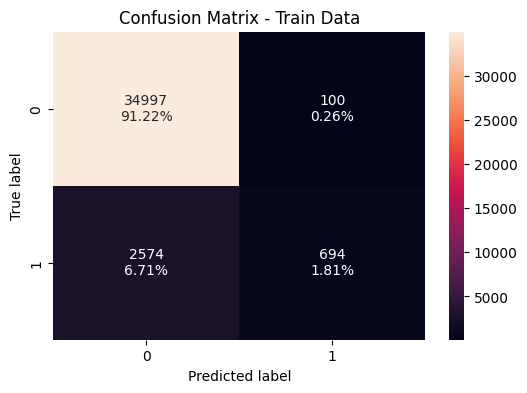

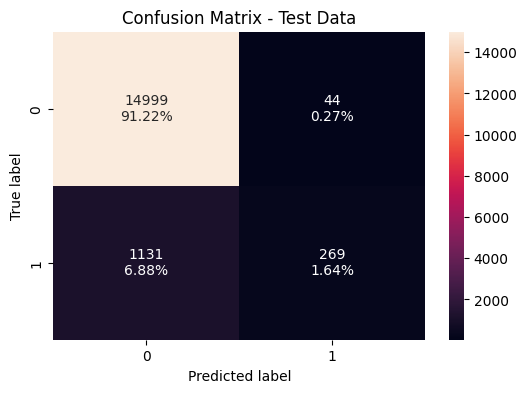


DecisionTreeClassifier_perf_train:
    Accuracy    Recall  Precision        F1
0  0.999583  0.995104        1.0  0.997546

DecisionTreeClassifier_perf_test:
    Accuracy    Recall  Precision        F1
0  0.874293  0.347143   0.296522  0.319842

BaggingClassifier_perf_train:
    Accuracy    Recall  Precision        F1
0  0.988192  0.864443   0.996473  0.925774

BaggingClassifier_perf_test:
    Accuracy  Recall  Precision        F1
0  0.926048   0.275   0.656997  0.387714

RandomForestClassifier_perf_train:
    Accuracy    Recall  Precision        F1
0  0.999557  0.994798        1.0  0.997392

RandomForestClassifier_perf_test:
    Accuracy    Recall  Precision        F1
0   0.92769  0.210714   0.778364  0.331647

AdaBoostClassifier_perf_train:
    Accuracy    Recall  Precision        F1
0  0.925036  0.157895    0.80625  0.264074

AdaBoostClassifier_perf_test:
    Accuracy    Recall  Precision        F1
0  0.925865  0.163571   0.826715  0.273107

GradientBoostingClassifier_perf_train:
  

In [45]:
# ============================================
# Import Required Libraries
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    recall_score,
    f1_score,
    precision_score
)

# ============================================
# Initialize Models
# ============================================
# 1. Decision Tree Classifier
# 2. Bagging Classifier
# 3. Random Forest Classifier
# 4. AdaBoost Classifier
# 5. Gradient Boosting Classifier

dec_tree = DecisionTreeClassifier()
bagging = BaggingClassifier()
ran_for = RandomForestClassifier()
ada_boost = AdaBoostClassifier()
grad_boost = GradientBoostingClassifier()

# List of models to iterate over
models = [dec_tree, bagging, ran_for, ada_boost, grad_boost]

# ============================================
# Model Training and Evaluation
# ============================================

# Create a dictionary to store performance results
performance_results = {}

# Train and evaluate each model
for model in models:
    # Fit model on training data
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Display model name and separator
    print(f"Model: {model.__class__.__name__}")
    print('-' * 120)

    # Confusion Matrix - Train Data
    confusion_matrix_sklearn(model, X_train, y_train, title="Confusion Matrix - Train Data")

    # Store training performance
    performance_results[f"{model.__class__.__name__}_perf_train"] = model_performance_classification_sklearn(
        model, X_train, y_train
    )

    # Confusion Matrix - Test Data
    confusion_matrix_sklearn(model, X_test, y_test, title="Confusion Matrix - Test Data")

    # Store test performance
    performance_results[f"{model.__class__.__name__}_perf_test"] = model_performance_classification_sklearn(
        model, X_test, y_test
    )

# ============================================
# Display Performance Results
# ============================================
for name, result in performance_results.items():
    print(f"\n{name}:\n", result)


In [46]:
# Print results into one dataframe for all the 5 models
combined_df = pd.DataFrame()

for key, df in performance_results.items():
    model_name, dataset_type = key.replace('_perf_', '_').split('_')
    df['Model'] = model_name
    df['Dataset'] = dataset_type
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Reorder columns
combined_df = combined_df[['Model', 'Dataset', 'Accuracy', 'Recall', 'Precision', 'F1']]

# Display result
print(combined_df)

                        Model Dataset  Accuracy    Recall  Precision        F1
0      DecisionTreeClassifier   train  0.999583  0.995104   1.000000  0.997546
1      DecisionTreeClassifier    test  0.874293  0.347143   0.296522  0.319842
2           BaggingClassifier   train  0.988192  0.864443   0.996473  0.925774
3           BaggingClassifier    test  0.926048  0.275000   0.656997  0.387714
4      RandomForestClassifier   train  0.999557  0.994798   1.000000  0.997392
5      RandomForestClassifier    test  0.927690  0.210714   0.778364  0.331647
6          AdaBoostClassifier   train  0.925036  0.157895   0.806250  0.264074
7          AdaBoostClassifier    test  0.925865  0.163571   0.826715  0.273107
8  GradientBoostingClassifier   train  0.930301  0.212362   0.874055  0.341704
9  GradientBoostingClassifier    test  0.928541  0.192143   0.859425  0.314069


### Observations
- Decision Tree Classifier : Highly overfitted (As Training score is excellent but large drop on test score)
- Bagging Classifier : Overfitted (The overfitting is reduces as compared to decision tree classifier)
- Random Forest Classifier : Overfitted (This is again overfitted)
- AdaBoost Classifier : Balanced (Good generalization between train and test data)
- Gradient Boosting Classifier : Balanced (Good generalization between train and test data)


##### Both Adaboost and Gradient boost are having good generalization but bad Recall score. That needs to be handled

### Criteria 4
### Model building - Oversampled data
- Oversample the train data
- Build 5 models (from decision trees, bagging and boosting methods)
- Comment on the model performance

You can choose NOT to build XGBoost if you are facing issues with the installation

In [47]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

Model : DecisionTreeClassifier
-----------------------------------------------------------------------------------------------------------------------


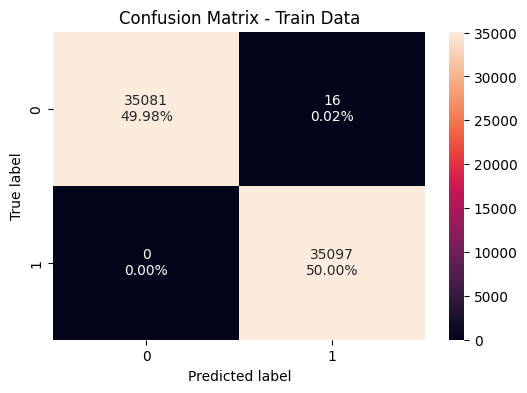

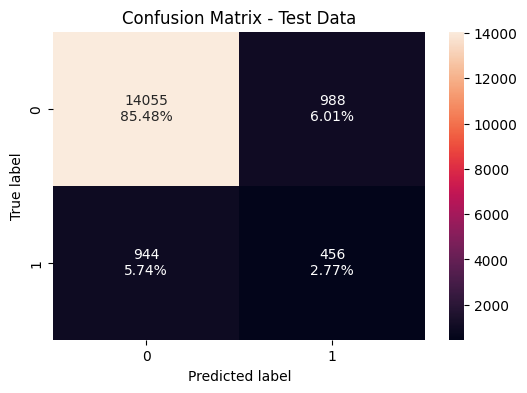

Model : BaggingClassifier
-----------------------------------------------------------------------------------------------------------------------


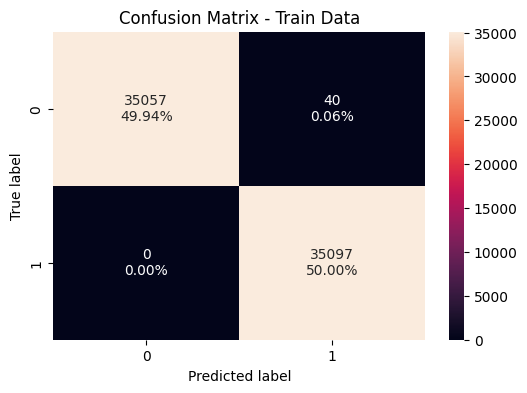

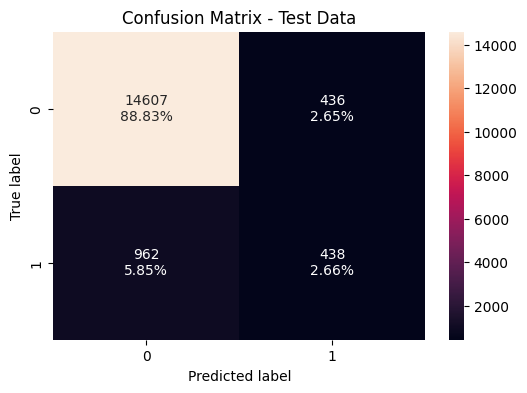

Model : RandomForestClassifier
-----------------------------------------------------------------------------------------------------------------------


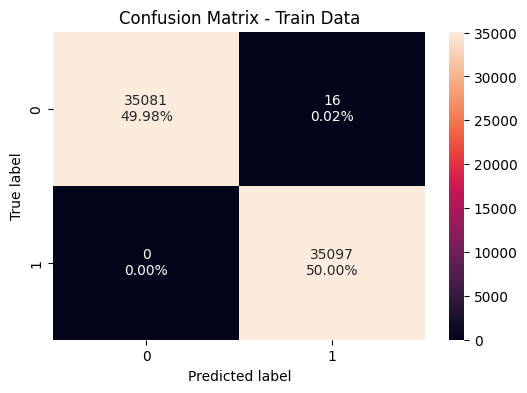

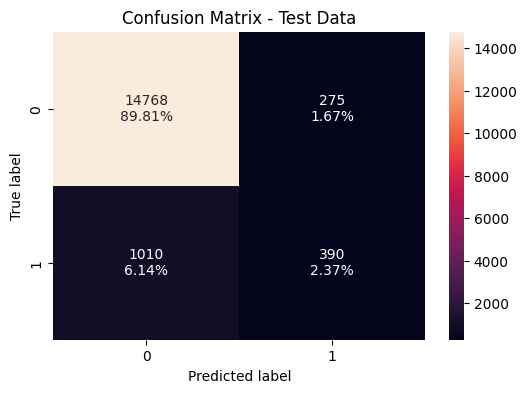

Model : AdaBoostClassifier
-----------------------------------------------------------------------------------------------------------------------


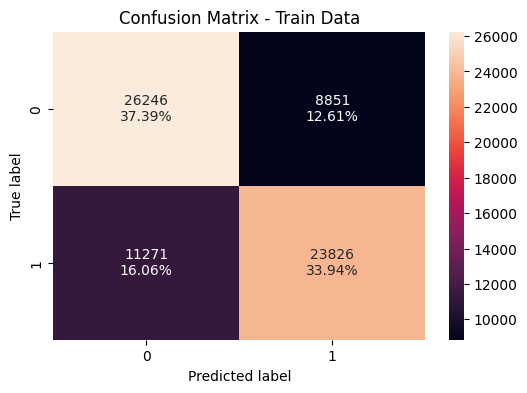

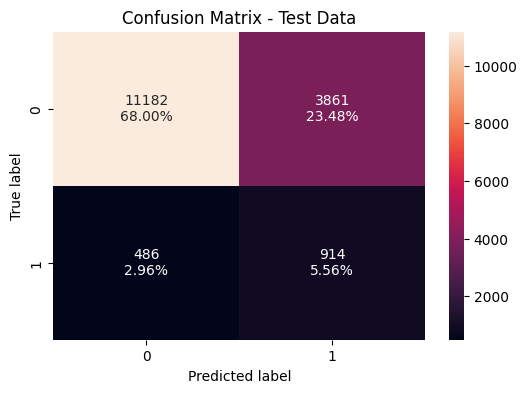

Model : GradientBoostingClassifier
-----------------------------------------------------------------------------------------------------------------------


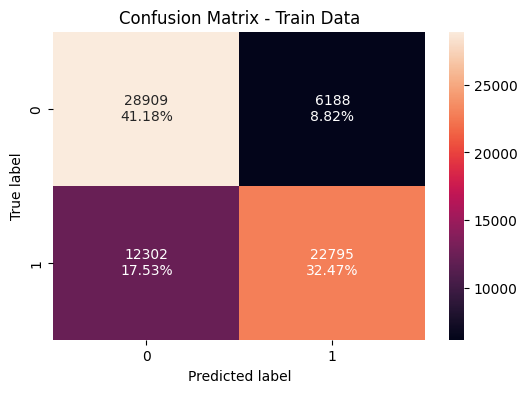

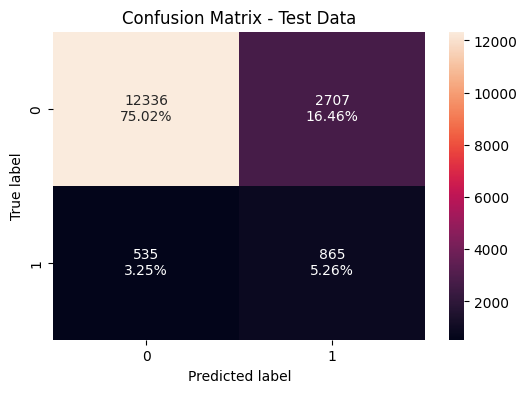


DecisionTreeClassifier_perf_train:
    Accuracy  Recall  Precision        F1
0  0.999772     1.0   0.999544  0.999772

DecisionTreeClassifier_perf_test:
    Accuracy    Recall  Precision        F1
0  0.882503  0.325714   0.315789  0.320675

BaggingClassifier_perf_train:
    Accuracy  Recall  Precision       F1
0   0.99943     1.0   0.998862  0.99943

BaggingClassifier_perf_test:
    Accuracy    Recall  Precision        F1
0  0.914979  0.312857   0.501144  0.385224

RandomForestClassifier_perf_train:
    Accuracy  Recall  Precision        F1
0  0.999772     1.0   0.999544  0.999772

RandomForestClassifier_perf_test:
    Accuracy    Recall  Precision        F1
0  0.921851  0.278571   0.586466  0.377724

AdaBoostClassifier_perf_train:
    Accuracy    Recall  Precision        F1
0  0.713337  0.678861   0.729137  0.703101

AdaBoostClassifier_perf_test:
    Accuracy    Recall  Precision        F1
0  0.735632  0.652857   0.191414  0.296032

GradientBoostingClassifier_perf_train:
    Accuracy

In [48]:
# We would initialize same 5 models with oversampling. 
# 1. Decision Tree Classifier
# 2. Bagging Classifier
# 3. Random Forest Classifier
# 4. AdaBoost Classifier
# 5. Gradient Boosting Classifier


dec_tree_over = DecisionTreeClassifier()
bagging_over = BaggingClassifier()
ran_for_over = RandomForestClassifier()
ada_boost_over = AdaBoostClassifier()
grad_boost_over = GradientBoostingClassifier()

models = [dec_tree_over, bagging_over, ran_for_over, ada_boost_over, grad_boost_over]

# Create a dictionary to store performance results
performance_results = {}

for model in models:
    model.fit(X_train_over, y_train_over)
    ypred = model.predict(X_test)
    
    print('Model :', model.__class__.__name__)
    print('-----------------------------------------------------------------------------------------------------------------------')

    confusion_matrix_sklearn(model, X_train_over, y_train_over, title="Confusion Matrix - Train Data")

    # Save performance results in dictionary
    performance_results[f"{model.__class__.__name__}_perf_train"] = model_performance_classification_sklearn(
        model, X_train_over, y_train_over
    )

    confusion_matrix_sklearn(model, X_test, y_test, title="Confusion Matrix - Test Data")
    
    # Save performance results in dictionary
    performance_results[f"{model.__class__.__name__}_perf_test"] = model_performance_classification_sklearn(
        model, X_test, y_test
    )

# To view results:
for name, result in performance_results.items():
    print(f"\n{name}:\n", result)


In [49]:
# Print results into one dataframe for all the 5 models
combined_df = pd.DataFrame()

for key, df in performance_results.items():
    model_name, dataset_type = key.replace('_perf_', '_').split('_')
    df['Model'] = model_name
    df['Dataset'] = dataset_type
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Reorder columns
combined_df = combined_df[['Model', 'Dataset', 'Accuracy', 'Recall', 'Precision', 'F1']]

# Display result
print(combined_df)

                        Model Dataset  Accuracy    Recall  Precision        F1
0      DecisionTreeClassifier   train  0.999772  1.000000   0.999544  0.999772
1      DecisionTreeClassifier    test  0.882503  0.325714   0.315789  0.320675
2           BaggingClassifier   train  0.999430  1.000000   0.998862  0.999430
3           BaggingClassifier    test  0.914979  0.312857   0.501144  0.385224
4      RandomForestClassifier   train  0.999772  1.000000   0.999544  0.999772
5      RandomForestClassifier    test  0.921851  0.278571   0.586466  0.377724
6          AdaBoostClassifier   train  0.713337  0.678861   0.729137  0.703101
7          AdaBoostClassifier    test  0.735632  0.652857   0.191414  0.296032
8  GradientBoostingClassifier   train  0.736587  0.649486   0.786496  0.711454
9  GradientBoostingClassifier    test  0.802834  0.617857   0.242161  0.347949


#### Observations

- Decision Tree Classifier : No major change. Still overfitting. Recall dropper further
- Bagging Classifier : Train accuracy good. Test accuracy improved little. But recall is still low. 
- Random Forest Classifier : Recall and F1 score still low on test dat. 
- AdaBoost Classifier : Less overfitting. But precision on test is very poort. That means many false positives
- Gradient Boosting Classifier : Over all good. But test precision is still weak 

### Criteria 5
### Model building - Undersampled data
- Undersample the train data
- Build 5 models (from decision trees, bagging and boosting methods)
- Comment on the model performance

You can choose NOT to build XGBoost if you are facing issues with the installation

In [50]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

Model : DecisionTreeClassifier
-----------------------------------------------------------------------------------------------------------------------


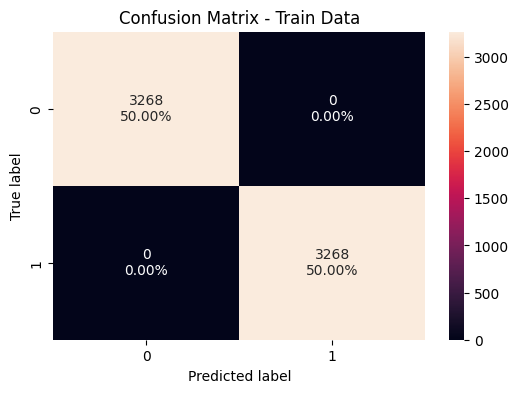

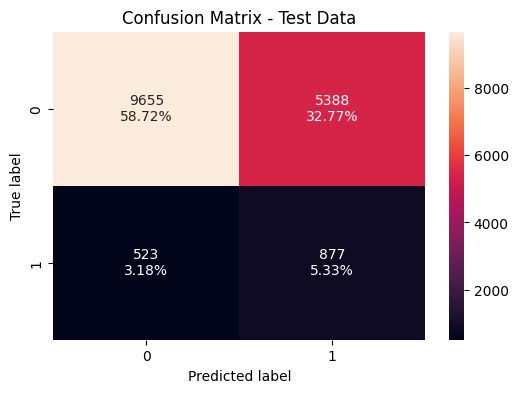

Model : BaggingClassifier
-----------------------------------------------------------------------------------------------------------------------


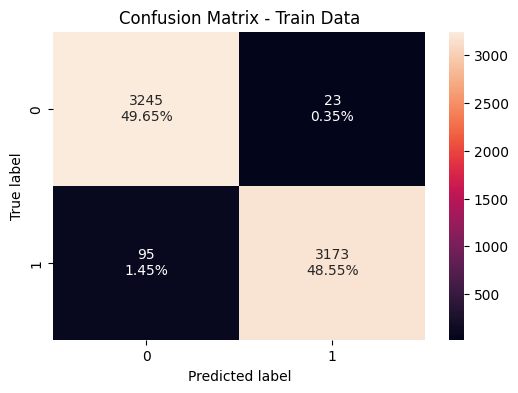

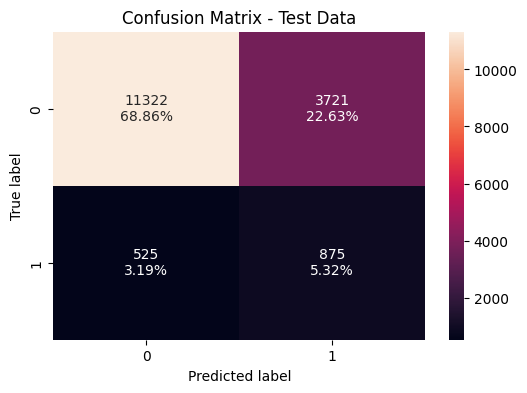

Model : RandomForestClassifier
-----------------------------------------------------------------------------------------------------------------------


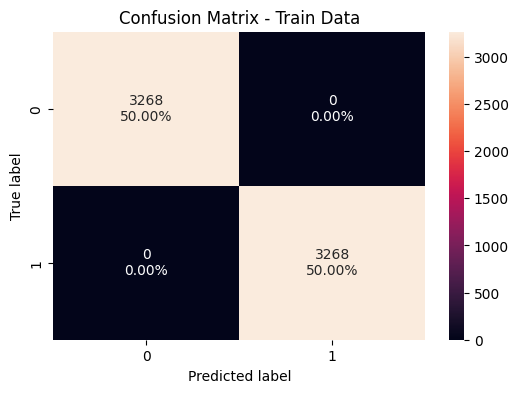

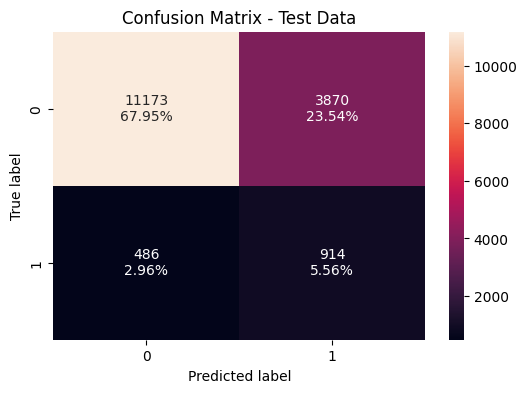

Model : AdaBoostClassifier
-----------------------------------------------------------------------------------------------------------------------


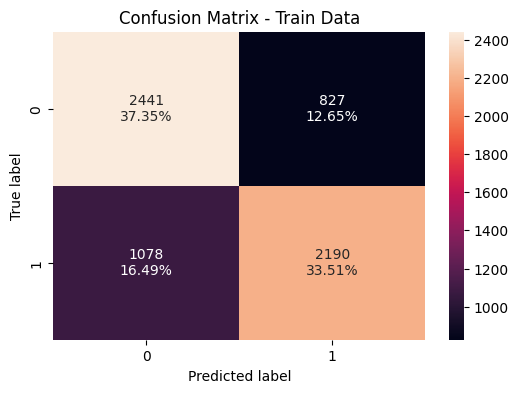

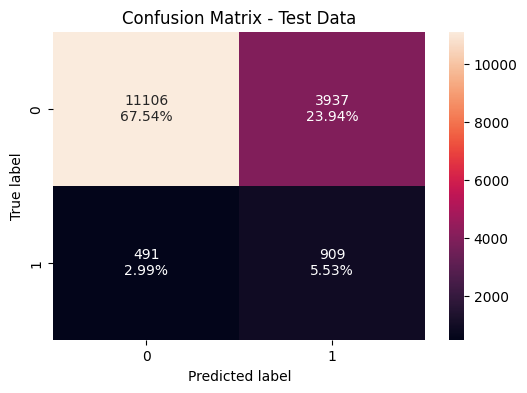

Model : GradientBoostingClassifier
-----------------------------------------------------------------------------------------------------------------------


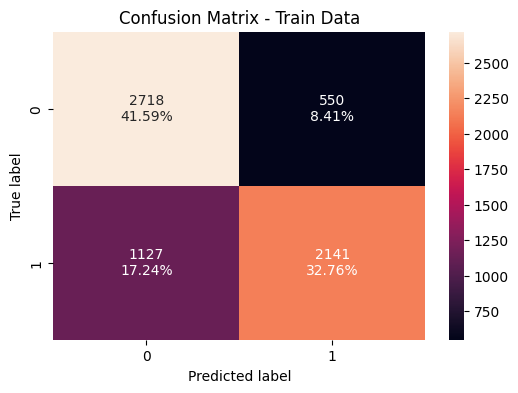

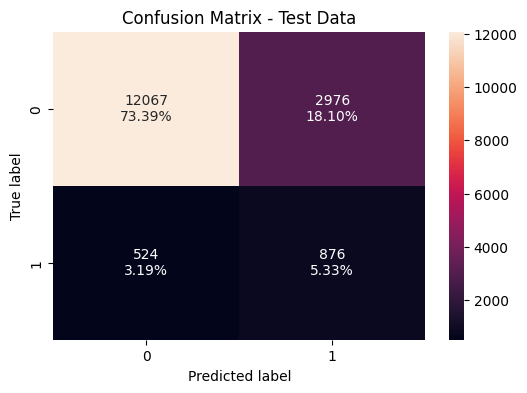


DecisionTreeClassifier_perf_train:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0

DecisionTreeClassifier_perf_test:
    Accuracy    Recall  Precision        F1
0  0.640516  0.626429   0.139984  0.228832

BaggingClassifier_perf_train:
    Accuracy   Recall  Precision        F1
0  0.981946  0.97093   0.992804  0.981745

BaggingClassifier_perf_test:
    Accuracy  Recall  Precision        F1
0  0.741775   0.625   0.190383  0.291861

RandomForestClassifier_perf_train:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0

RandomForestClassifier_perf_test:
    Accuracy    Recall  Precision        F1
0  0.735085  0.652857   0.191054  0.295602

AdaBoostClassifier_perf_train:
    Accuracy    Recall  Precision        F1
0  0.708537  0.670135   0.725887  0.696897

AdaBoostClassifier_perf_test:
    Accuracy    Recall  Precision        F1
0  0.730706  0.649286   0.187577  0.291066

GradientBoostingClassifier_perf_train:
    Accuracy    Recall  Precisio

In [51]:
# We would initialize same 5 models with oversampling. 
# 1. Decision Tree Classifier
# 2. Bagging Classifier
# 3. Random Forest Classifier
# 4. AdaBoost Classifier
# 5. Gradient Boosting Classifier


dec_tree_under = DecisionTreeClassifier()
bagging_under = BaggingClassifier()
ran_for_under = RandomForestClassifier()
ada_boost_under = AdaBoostClassifier()
grad_boost_under = GradientBoostingClassifier()

models = [dec_tree_under, bagging_under, ran_for_under, ada_boost_under, grad_boost_under]

# Create a dictionary to store performance results
performance_results = {}

for model in models:
    model.fit(X_train_under, y_train_under)
    ypred = model.predict(X_test)
    
    print('Model :', model.__class__.__name__)
    print('-----------------------------------------------------------------------------------------------------------------------')

    confusion_matrix_sklearn(model, X_train_under, y_train_under, title="Confusion Matrix - Train Data")

    # Save performance results in dictionary
    performance_results[f"{model.__class__.__name__}_perf_train"] = model_performance_classification_sklearn(
        model, X_train_under, y_train_under
    )

    confusion_matrix_sklearn(model, X_test, y_test, title="Confusion Matrix - Test Data")
    
    # Save performance results in dictionary
    performance_results[f"{model.__class__.__name__}_perf_test"] = model_performance_classification_sklearn(
        model, X_test, y_test
    )

# To view results:
for name, result in performance_results.items():
    print(f"\n{name}:\n", result)


In [52]:
# Print results into one dataframe for all the 5 models
combined_df = pd.DataFrame()

for key, df in performance_results.items():
    model_name, dataset_type = key.replace('_perf_', '_').split('_')
    df['Model'] = model_name
    df['Dataset'] = dataset_type
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Reorder columns
combined_df = combined_df[['Model', 'Dataset', 'Accuracy', 'Recall', 'Precision', 'F1']]

# Display result
print(combined_df)

                        Model Dataset  Accuracy    Recall  Precision        F1
0      DecisionTreeClassifier   train  1.000000  1.000000   1.000000  1.000000
1      DecisionTreeClassifier    test  0.640516  0.626429   0.139984  0.228832
2           BaggingClassifier   train  0.981946  0.970930   0.992804  0.981745
3           BaggingClassifier    test  0.741775  0.625000   0.190383  0.291861
4      RandomForestClassifier   train  1.000000  1.000000   1.000000  1.000000
5      RandomForestClassifier    test  0.735085  0.652857   0.191054  0.295602
6          AdaBoostClassifier   train  0.708537  0.670135   0.725887  0.696897
7          AdaBoostClassifier    test  0.730706  0.649286   0.187577  0.291066
8  GradientBoostingClassifier   train  0.743421  0.655141   0.795615  0.718577
9  GradientBoostingClassifier    test  0.787143  0.625714   0.227414  0.333587


#### Observations with underfit model

- Decision Tree Classifier : Large overfitting. 
- Bagging Classifier : Better in generalization. but still weak precision on test
- Random Forest Classifier :  Large overfitting
- AdaBoost Classifier : Good generalization but poor precision on test
- Gradient Boosting Classifier : Good generalization. F1 and Recall is highest among all boosting models. 

### Criteria 6
#### Model Performance Improvement using Hyperparameter Tuning

- Choose models that might perform better after tuning (tune at least 3 models out of 15 built in the previous steps)
- Provide proper reasoning for tuning that model
- Tune the best 3 models obtained above using randomized search and metric of interest
- Check the performance of 3 tuned models

#### Out of 15 models, we will choose below 3 model. As they are not overfitting or underfitting and having good generalization between train and test

- Gradient Boosting Classifier with undersampling : F1 and Recall is highest. Not overfitting. 
- Gradient Boosting Classifier with oversampling : Good generalization (But test precision is weak)
- Bagging Classifier (without under sampling or over sampling) : As it has good F1 score (but overfitting)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best hyperparameters: {'learning_rate': 0.16111022770860975, 'max_depth': 3, 'min_samples_split': 8, 'n_estimators': 286, 'subsample': 0.9084354799119113}


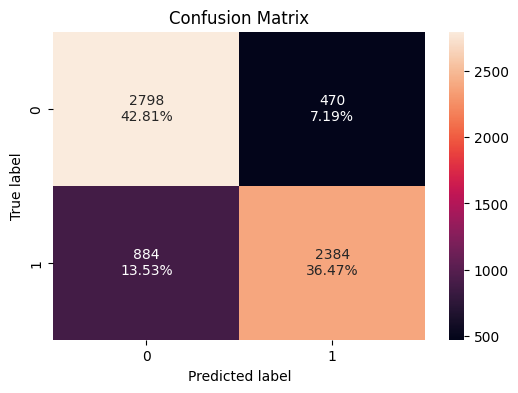

,Accuracy,Recall,Precision,F1
0,0.79284,0.729498,0.835319,0.77883


In [53]:
# Create a dictionary to store performance results
performance_results = {}

#Hyperparameter tuning for Gradient Boosting Classifier with undersampling

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

gbc = GradientBoostingClassifier(random_state=42)

param_dist = {
    'n_estimators': randint(100, 500),          # number of boosting rounds
    'learning_rate': uniform(0.01, 0.2),       # learning rate from 0.01 to 0.21
    'max_depth': randint(3, 6),                # depth of individual trees
    'subsample': uniform(0.7, 0.3),            # fraction of samples per tree (0.7 to 1.0)
    'min_samples_split': randint(2, 20)        # minimum samples required to split
}

random_search = RandomizedSearchCV(
    estimator=gbc,
    param_distributions=param_dist,
    n_iter=50,               # number of random combinations to try
    scoring='f1',            # optimize F1 for imbalanced dataset
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_under, y_train_under)

best_gbc_under = random_search.best_estimator_
# y_pred = best_gbc.predict(X_test)

print("Best hyperparameters:", random_search.best_params_)
# print("\nClassification Report:\n", classification_report(y_test, y_pred))
# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

best_gbc_under.fit(X_train_under, y_train_under)
confusion_matrix_sklearn(best_gbc_under, X_train_under, y_train_under)

best_gbc_under_model_train_perf = model_performance_classification_sklearn(
    best_gbc_under, X_train_under, y_train_under
)

# Save performance results in dictionary
performance_results["Gradient_Boosting_Under_Sampling"] = model_performance_classification_sklearn(
        best_gbc_under, X_train_under, y_train_under
    )

best_gbc_under_model_train_perf

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best hyperparameters: {'learning_rate': 0.18921825998469866, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 484, 'subsample': 0.7683805487625824}


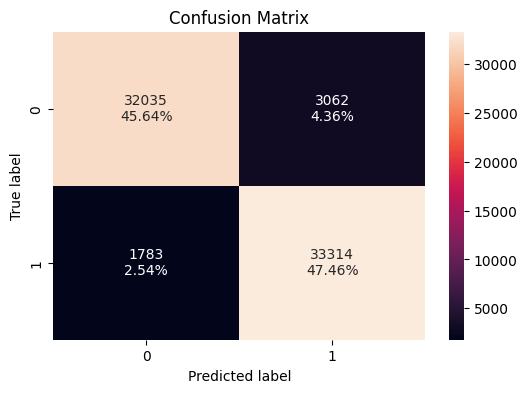

,Accuracy,Recall,Precision,F1
0,0.930977,0.949198,0.915824,0.932212


In [54]:
#Hyperparameter tuning for Gradient Boosting Classifier with oversampling

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

gbc = GradientBoostingClassifier(random_state=42)

param_dist = {
    'n_estimators': randint(100, 500),          # number of boosting rounds
    'learning_rate': uniform(0.01, 0.2),       # learning rate from 0.01 to 0.21
    'max_depth': randint(3, 6),                # depth of individual trees
    'subsample': uniform(0.7, 0.3),            # fraction of samples per tree (0.7 to 1.0)
    'min_samples_split': randint(2, 20)        # minimum samples required to split
}

random_search = RandomizedSearchCV(
    estimator=gbc,
    param_distributions=param_dist,
    n_iter=50,               # number of random combinations to try
    scoring='f1',            # optimize F1 for imbalanced dataset
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_over, y_train_over)

best_gbc_over = random_search.best_estimator_
# y_pred = best_gbc.predict(X_test)

print("Best hyperparameters:", random_search.best_params_)
# print("\nClassification Report:\n", classification_report(y_test, y_pred))
# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

best_gbc_over.fit(X_train_over, y_train_over)
confusion_matrix_sklearn(best_gbc_over, X_train_over, y_train_over)

best_gbc_over_model_train_perf = model_performance_classification_sklearn(
    best_gbc_over, X_train_over, y_train_over
)

# Save performance results in dictionary
performance_results["Gradient_Boosting_Over_Sampling"] = model_performance_classification_sklearn(
        best_gbc_over, X_train_over, y_train_over
    )

best_gbc_over_model_train_perf

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END learning_rate=0.038573363584388155, max_depth=5, min_samples_split=3, n_estimators=443, subsample=0.9497327922401264; total time=   2.0s
[CV] END learning_rate=0.013193250444042839, max_depth=4, min_samples_split=16, n_estimators=363, subsample=0.7103165563345655; total time=   1.1s
[CV] END learning_rate=0.07530815376116708, max_depth=4, min_samples_split=9, n_estimators=312, subsample=0.8166031869068445; total time=   1.1s
[CV] END learning_rate=0.0430533878126005, max_depth=3, min_samples_split=8, n_estimators=108, subsample=0.9316734307889971; total time=   0.3s
[CV] END learning_rate=0.19299193510875617, max_depth=3, min_samples_split=9, n_estimators=367, subsample=0.7992694074557947; total time=   1.0s
[CV] END learning_rate=0.06494435859801283, max_depth=5, min_samples_split=2, n_estimators=326, subsample=0.7358782737814905; total time=   1.3s
[CV] END learning_rate=0.11171413823294056, max_depth=4, min_sampl

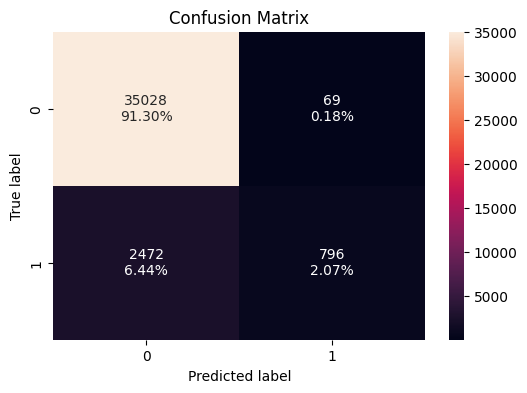

,Accuracy,Recall,Precision,F1
0,0.933768,0.243574,0.920231,0.385192


In [55]:
#Hyperparameter tuning for Bagging Classifier

bag_clf = BaggingClassifier(base_estimator=DecisionTreeClassifier(random_state=42),
                            random_state=42)

param_dist = {
    'n_estimators': randint(50, 300),        # number of base estimators
    'max_samples': uniform(0.5, 0.5),        # fraction of samples for each estimator
    'max_features': uniform(0.5, 0.5),       # fraction of features for each estimator
    'bootstrap': [True, False],              # bootstrap sampling
    'bootstrap_features': [True, False],     # bootstrap features
    'base_estimator__max_depth': randint(1, 10),   # optional: depth of trees
    'base_estimator__min_samples_split': randint(2, 20)
}

random_search = RandomizedSearchCV(
    estimator=bag_clf,
    param_distributions=param_dist,
    n_iter=50,             # number of random combinations
    scoring='f1',          # optimize F1 score for imbalanced data
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)


best_bag = random_search.best_estimator_
# y_pred = best_gbc.predict(X_test)

print("Best hyperparameters:", random_search.best_params_)
# print("\nClassification Report:\n", classification_report(y_test, y_pred))
# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

best_bag.fit(X_train, y_train)
confusion_matrix_sklearn(best_bag, X_train, y_train)

best_bagging_model_train_perf = model_performance_classification_sklearn(
    best_bag, X_train, y_train
)

# Save performance results in dictionary
performance_results["Bagging_Classifier"] = model_performance_classification_sklearn(
        best_bag, X_train, y_train
    )

best_bagging_model_train_perf



### Criteria 7
#### Model Performances and Final Model Selection

- Compare the performance of tuned models
- Choose the best model
- Comment on the performance of the best model on the test set

In [56]:
# Print results into one dataframe for all the 3 models for which we did hyper parameters tuning above. 
combined_df = pd.DataFrame()

for key, df in performance_results.items():
    df['Model'] = key
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Reorder columns
combined_df = combined_df[['Model', 'Accuracy', 'Recall', 'Precision', 'F1']]

# Display result
print(combined_df)


                              Model  Accuracy    Recall  Precision        F1
0  Gradient_Boosting_Under_Sampling  0.792840  0.729498   0.835319  0.778830
1   Gradient_Boosting_Over_Sampling  0.930977  0.949198   0.915824  0.932212
2                Bagging_Classifier  0.933768  0.243574   0.920231  0.385192


#### Observations
- Gradient Boosting with over sampling is the best model as it has highest F1 score and good accuracy on train data. 

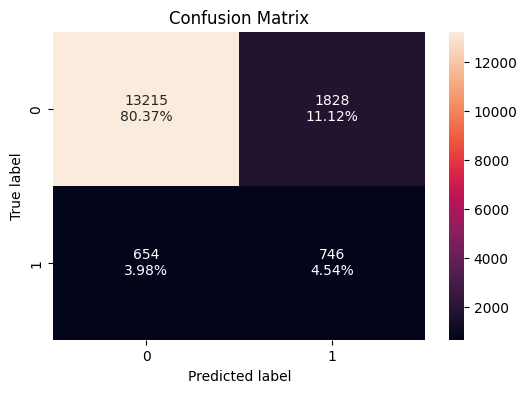

,Accuracy,Recall,Precision,F1
0,0.849054,0.532857,0.289821,0.37544


/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWar

[CV] END learning_rate=0.038573363584388155, max_depth=5, min_samples_split=3, n_estimators=443, subsample=0.9497327922401264; total time=   2.0s
[CV] END learning_rate=0.19186408041575642, max_depth=4, min_samples_split=9, n_estimators=487, subsample=0.7935133228268232; total time=   1.6s
[CV] END learning_rate=0.07530815376116708, max_depth=4, min_samples_split=9, n_estimators=312, subsample=0.8166031869068445; total time=   1.1s
[CV] END learning_rate=0.19299193510875617, max_depth=3, min_samples_split=9, n_estimators=367, subsample=0.7992694074557947; total time=   1.0s
[CV] END learning_rate=0.15264895744459903, max_depth=3, min_samples_split=6, n_estimators=317, subsample=0.7707954759246867; total time=   0.8s
[CV] END learning_rate=0.015083825348819038, max_depth=3, min_samples_split=8, n_estimators=340, subsample=0.794306794322898; total time=   0.9s
[CV] END learning_rate=0.18609356780305156, max_depth=4, min_samples_split=14, n_estimators=161, subsample=0.890021126953127; tot

/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWar

[CV] END learning_rate=0.0849080237694725, max_depth=3, min_samples_split=16, n_estimators=206, subsample=0.9339073000818308; total time=   0.6s
[CV] END learning_rate=0.052467822135655234, max_depth=3, min_samples_split=2, n_estimators=413, subsample=0.8574269294896713; total time=   1.1s
[CV] END learning_rate=0.012652992231973307, max_depth=3, min_samples_split=15, n_estimators=341, subsample=0.8156249507619748; total time=   0.9s
[CV] END learning_rate=0.1784569549189997, max_depth=4, min_samples_split=11, n_estimators=369, subsample=0.9181815987569262; total time=   1.3s
[CV] END learning_rate=0.0430533878126005, max_depth=3, min_samples_split=8, n_estimators=108, subsample=0.9316734307889971; total time=   0.3s
[CV] END learning_rate=0.16803510810624114, max_depth=5, min_samples_split=6, n_estimators=330, subsample=0.8953231076505833; total time=   1.4s
[CV] END learning_rate=0.15264895744459903, max_depth=3, min_samples_split=6, n_estimators=317, subsample=0.7707954759246867; to

...

[CV] END learning_rate=0.038573363584388155, max_depth=5, min_samples_split=3, n_estimators=443, subsample=0.9497327922401264; total time=   2.0s
[CV] END learning_rate=0.013193250444042839, max_depth=4, min_samples_split=16, n_estimators=363, subsample=0.7103165563345655; total time=   1.1s
[CV] END learning_rate=0.1784569549189997, max_depth=4, min_samples_split=11, n_estimators=369, subsample=0.9181815987569262; total time=   1.3s
[CV] END learning_rate=0.19299193510875617, max_depth=3, min_samples_split=9, n_estimators=367, subsample=0.7992694074557947; total time=   1.0s
[CV] END learning_rate=0.06494435859801283, max_depth=5, min_samples_split=2, n_estimators=326, subsample=0.7358782737814905; total time=   1.3s
[CV] END learning_rate=0.11171413823294056, max_depth=4, min_samples_split=6, n_estimators=330, subsample=0.8231148769106889; total time=   1.1s
[CV] END learning_rate=0.18921825998469866, max_depth=5, min_samples_split=2, n_estimators=484, subsample=0.7683805487625824; t

/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWar

[CV] END learning_rate=0.052467822135655234, max_depth=3, min_samples_split=2, n_estimators=413, subsample=0.8574269294896713; total time=   1.1s
[CV] END learning_rate=0.10121399684340719, max_depth=5, min_samples_split=13, n_estimators=154, subsample=0.9949692657420364; total time=   0.7s
[CV] END learning_rate=0.013193250444042839, max_depth=4, min_samples_split=16, n_estimators=363, subsample=0.7103165563345655; total time=   1.1s
[CV] END learning_rate=0.1784569549189997, max_depth=4, min_samples_split=11, n_estimators=369, subsample=0.9181815987569262; total time=   1.3s
[CV] END learning_rate=0.04974313630683449, max_depth=5, min_samples_split=12, n_estimators=180, subsample=0.9134025858245949; total time=   0.8s
[CV] END learning_rate=0.02271167005720473, max_depth=5, min_samples_split=6, n_estimators=198, subsample=0.8773893363123181; total time=   0.9s
[CV] END learning_rate=0.0612136645522648, max_depth=5, min_samples_split=10, n_estimators=306, subsample=0.8282623055075649;

/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/ws/nikhimeh-bgl/pyATS_CVT/pyats_nikhimeh/lib64/python3.8/site-packages/sklearn/ensemble/_base.py:156: FutureWar

[CV] END base_estimator__max_depth=3, base_estimator__min_samples_split=5, bootstrap=True, bootstrap_features=False, max_features=0.822736147953584, max_samples=0.5885553397035245, n_estimators=269; total time=   2.0s
[CV] END base_estimator__max_depth=7, base_estimator__min_samples_split=2, bootstrap=False, bootstrap_features=True, max_features=0.5847463733430462, max_samples=0.7784006312291751, n_estimators=272; total time=   3.4s
[CV] END base_estimator__max_depth=7, base_estimator__min_samples_split=2, bootstrap=False, bootstrap_features=True, max_features=0.5847463733430462, max_samples=0.7784006312291751, n_estimators=272; total time=   3.4s


In [57]:
confusion_matrix_sklearn(best_gbc_over, X_test, y_test)

best_gbc_over_model_test_perf= model_performance_classification_sklearn(
    best_gbc_over, X_test, y_test
)
best_gbc_over_model_test_perf

### Criteria 8
#### Actionable Insights & Recommendations

- Write down insights from the analysis conducted
- Provide actionable business recommendations

### Below is the insights from the above analysis
- Only about 8% of the employees were promoted
- Those who won the awards last year have more chance of promotion
- Those who got higher performance ratings have more chance of promotion
- Promotion is done irrespecitve of department or gender
- Higher education is not the main driver for the promotion

### Below is the actionable business recommendations
- Previous year rating is one important factor but there were many missing values in this. We should capture it properly
- HR can use above model to prioratize candidates for manual review.
- Allocate promotion budget more strategically to the departments with hih performing employees who are currently under promoted
- Further we should combine this promotion prediction with employee satisfaction or attrition model as well